In [1]:
from pathlib import Path
import pandas as pd

measurement_folder = Path("Data/irradiation_measurements")
mak_measurement = measurement_folder / "MAK_physics_dept/"


In [131]:
kampala = pd.read_csv(mak_measurement / "kampala.csv")
tororo = pd.read_csv(mak_measurement / "tororo.csv")

kampala.index = pd.to_datetime(kampala['datetime'])
tororo.index = pd.to_datetime(tororo['datetime'])

# convert to KW/m2
kampala['ghi'] = kampala['ghi'] / 1000
tororo['ghi'] = tororo['ghi'] / 1000

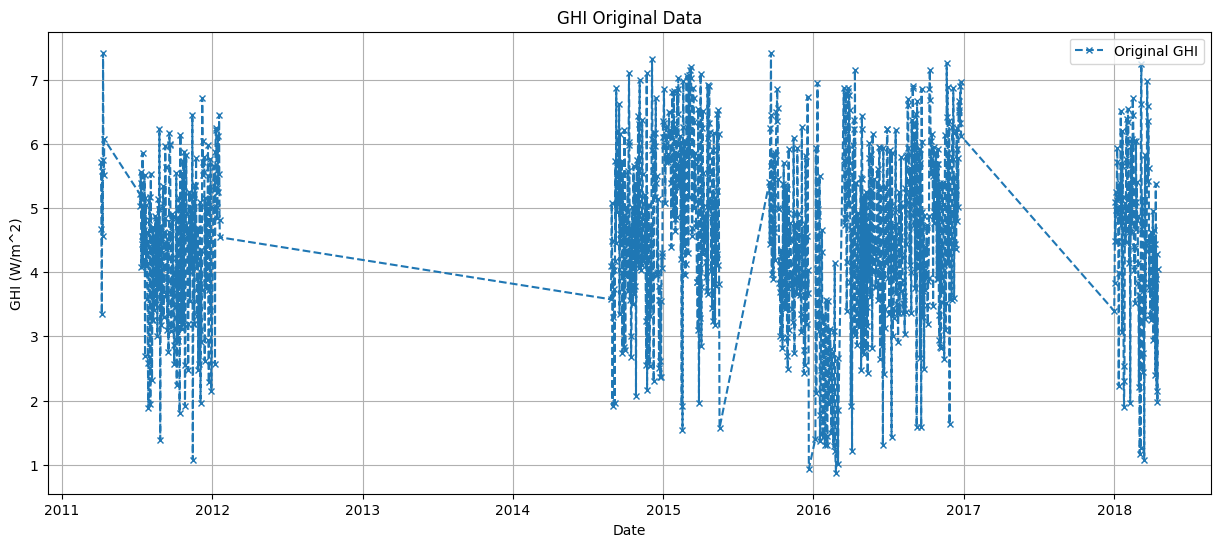

In [132]:
# plot the first 100 points of the predictions and the original data
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 6))
plt.plot(kampala.index[:1000],kampala['ghi'][:1000], label='Original GHI', marker='x', linestyle='--', markersize=4)
plt.title('GHI Original Data')
plt.xlabel('Date')
plt.ylabel('GHI (W/m^2)')
plt.legend()
plt.grid()
plt.show()

In [7]:
#@title Compute altitude
import pvlib
def get_altitude_pvib(df):

    locations = df['location'].unique()

    for location in locations:
        latitude = df[df['location'] == location]['latitude'].iloc[0]
        longitude = df[df['location'] == location]['longitude'].iloc[0]
        altitude = pvlib.location.lookup_altitude(latitude, longitude)
        df.loc[df['location'] == location, 'altitude'] = altitude

    return df

In [8]:
def extract_location_metadata(df):
    """
    Reads the time range of the ground data and the coordinates of the station

    Args:
        df (pd.DataFrame): Dataframe with the ground data

    Returns:
        dictionary: Dictionary with the time range, location and coordinates
    """
    if not all(col in df.columns for col in ['location', 'datetime', 'latitude', 'longitude']):
        raise ValueError("Input DataFrame must contain 'location', 'datetime', 'latitude', 'longitude' columns.")
    if not pd.api.types.is_datetime64_any_dtype(df['datetime']):
         df['datetime'] = pd.to_datetime(df['datetime'])

    locations = df['location'].unique()
    metadata_dict = {}

    for location in locations:
        location_df = df[df['location'] == location].copy()
        start_time = location_df['datetime'].min()
        end_time = location_df['datetime'].max()

        # Get the coordinates from the first row
        lat = location_df['latitude'].iloc[0]
        lon = location_df['longitude'].iloc[0]

        metadata = {
            'Location': location,
            'Start Time': start_time.strftime('%Y-%m-%d'),
            'End Time': end_time.strftime('%Y-%m-%d'),
            'Latitude': lat,
            'Longitude': lon
        }
        metadata_dict[location] = metadata
    return metadata_dict
loc_dict = {}

In [9]:
kampala_dict = extract_location_metadata(kampala)
tororo_dict = extract_location_metadata(tororo)

## NASA Pull

In [19]:
nasa_features = [
  'ALLSKY_SFC_SW_DWN',   # Satellite GHI Avg
  'ALLSKY_SFC_SW_DIFF',  # Satellite DHI Avg
  'ALLSKY_SFC_SW_DNI',   # Satellite DNI Avg
  'CLRSKY_SFC_LW_DWN',   # Satellite Clear GHI Avg
  'T2M',                 # Daily Avg Temp
  'RH2M',                # Daily Avg RH
  'PS',                  # Daily Avg Pressure
  'WS2M',                # Daily Avg Wind Speed
  'AOD_55_ADJ',          # Daily Avg AOD (Adjusted)
  'CLOUD_AMT',           # Daily Avg Cloud Amount
  'PW',                  # Daily Avg Precipitable Water
  'T2M_RANGE',           # Daily Temp Range
  'PRECTOTCORR',         # Daily Precip Total
  'Z0M',               # Surface Roughness
  'V2M',               # Northward Wind at 2M
  'AIRMASS',           # Airmass
  'DISPH',             # Zero Plane Displacement Height
  'EVPTRNS',           # Evapotranspiration Energy Flux
  'PBLTOP',            # Planetary Boundary Layer Top Pressure
  'TO3',               # Total Column Ozone
  'RHOA',              # Surface Air Density
  'SRF_ALB_ADJ',       # Surface Albedo Adjusted
  'EVLAND',            # Evaporation Land
  'GWETTOP',           # Surface Soil Wetness
  'ALLSKY_KT'          # All Sky Insolation Clearness Index
]

In [133]:
#@title Nasa pull
import pandas as pd
import requests
from io import StringIO
import math
import time
from requests.exceptions import Timeout


NASA_POWER_BATCH_SIZE = 20
NASA_POWER_BASE_URL = "https://power.larc.nasa.gov/api/temporal/daily/point?parameters={parameters_str}&community=RE&longitude={longitude}&latitude={latitude}&start={start}&end={end}&format=CSV"
NASA_MISSING_VALUE = -999

def fetch_nasa_power_data_batched(locations_dict, parameters_list, estimator="nasa_power", request_delay_sec=0.001):
    """
    Fetch daily data from NASA POWER API for multiple locations, handling parameter batching.

    Args:
        locations_dict (dict): Dictionary with location details from extract_location_metadata.
        parameters_list (list): List of strings for ALL desired NASA POWER parameters.
        estimator (str): Name to assign to the 'estimator' column.
        request_delay_sec (float): Optional delay (in seconds) between API requests to avoid
                                   hitting rate limits. Default is 0.5 seconds.

    Returns:
        tuple: (pd.DataFrame, dict)
            - DataFrame containing data for ALL requested parameters and locations,
              with columns for each parameter, plus 'location' and 'estimator'.
              Index is datetime.
            - Dictionary containing metadata strings for each location (from the first batch).
            Returns (pd.DataFrame(), {}) if fetching fails significantly.
    """
    if not isinstance(parameters_list, (list, tuple)):
        raise TypeError("`parameters_list` must be a list or tuple of parameter strings.")
    if not parameters_list:
        print("Warning: No parameters provided to fetch_nasa_power_data_batched.")
        return pd.DataFrame(), {}

    num_batches = math.ceil(len(parameters_list) / NASA_POWER_BATCH_SIZE)

    all_location_final_dfs = []
    metadata_dict = {}

    for location_name, details in locations_dict.items():
        start_date_api = details['Start Time'].replace("-", "")
        end_date_api = details['End Time'].replace("-", "")
        latitude = details['Latitude']
        longitude = details['Longitude']

        location_batch_dfs = []

        for i in range(num_batches):
            batch_start_idx = i * NASA_POWER_BATCH_SIZE
            batch_end_idx = batch_start_idx + NASA_POWER_BATCH_SIZE
            parameter_batch = parameters_list[batch_start_idx:batch_end_idx]
            parameters_str = ",".join(parameter_batch)

            api_url = NASA_POWER_BASE_URL.format(
                parameters_str=parameters_str,
                longitude=longitude,
                latitude=latitude,
                start=start_date_api,
                end=end_date_api
            )

            try:
                # Optional delay between requests
                # if request_delay_sec > 0 and (i > 0 or list(locations_dict.keys())[0] != location_name):
                #      time.sleep(request_delay_sec)

                response = requests.get(api_url, verify=True, timeout=90)
                response.raise_for_status()

                content = response.content.decode('utf-8')
                lines = content.split("\n")

                try:
                    header_row_index = next(i for i, line in enumerate(lines) if line.strip().startswith("YEAR,MO,DY"))
                except StopIteration:
                    print(f"  Warning: Could not find standard header 'YEAR,MO,DY...' in NASA POWER response for batch {i+1}, location {location_name}. Skipping batch.")
                    print(f"  Response content start:\n{content[:500]}")
                    continue

                if location_name not in metadata_dict:
                     metadata = "\n".join(lines[:header_row_index])
                     metadata_dict[location_name] = {"metadata": metadata}

                csv_data = StringIO("\n".join(lines[header_row_index:]))
                df_batch = pd.read_csv(csv_data, na_values={col: NASA_MISSING_VALUE for col in parameter_batch})


                if not all(col in df_batch.columns for col in ['YEAR', 'MO', 'DY']):
                     print(f"  Warning: Missing YEAR, MO, or DY columns in batch {i+1}, location {location_name}. Skipping batch.")
                     continue
                df_batch.rename(columns={"YEAR": "year", "MO": "month", "DY": "day"}, inplace=True)
                df_batch["datetime"] = pd.to_datetime(df_batch[["year", "month", "day"]])
                df_batch.set_index('datetime', inplace=True)

                cols_to_keep = [col for col in parameter_batch if col in df_batch.columns]
                if len(cols_to_keep) != len(parameter_batch):
                     missing_cols = set(parameter_batch) - set(cols_to_keep)
                     print(f"  Warning: Did not find all expected parameter columns in response for batch {i+1}. Missing: {missing_cols}")

                if not cols_to_keep:
                    print(f"  Warning: No valid parameter columns found in batch {i+1}, location {location_name}. Skipping batch.")
                    continue

                df_batch = df_batch[cols_to_keep]

                for col in df_batch.columns:
                    df_batch[col] = pd.to_numeric(df_batch[col], errors='coerce')

                location_batch_dfs.append(df_batch)


            except Timeout:
                 print(f"  Timeout error fetching NASA POWER data for batch {i+1}, location {location_name}")
            except requests.exceptions.RequestException as e:
                 print(f"  Failed to fetch NASA POWER data for batch {i+1}, location {location_name}: {e}")
            except Exception as e:
                 print(f"  An unexpected error occurred processing NASA POWER batch {i+1} for {location_name}: {e}")

        if location_batch_dfs:
            combined_loc_df = pd.concat(location_batch_dfs, axis=1)

            if combined_loc_df.columns.has_duplicates:
                 print(f"  Warning: Duplicate columns found after merging batches for {location_name}. Keeping first instance.")
                 combined_loc_df = combined_loc_df.loc[:, ~combined_loc_df.columns.duplicated(keep='first')]

            combined_loc_df['location'] = location_name
            combined_loc_df['estimator'] = estimator
            all_location_final_dfs.append(combined_loc_df)
            print(f"--- Finished processing location: {location_name} ---")
        else:
            print(f"--- No data successfully processed for location: {location_name} ---")

    if not all_location_final_dfs:
        print("\nNo NASA POWER data successfully fetched for any location.")
        return pd.DataFrame(), metadata_dict

    final_df = pd.concat(all_location_final_dfs, axis=0)

    id_cols = ['location', 'estimator']
    data_cols = [col for col in final_df.columns if col not in id_cols]
    final_df = final_df[id_cols + data_cols]

    print(f"\nSuccessfully combined NASA POWER data for {len(locations_dict)} locations.")
    return final_df, metadata_dict




# Fetch data for kampala
kampala_nasa, kampala_metadata = fetch_nasa_power_data_batched(kampala_dict, nasa_features, estimator="nasa_power", request_delay_sec=0.001)
# Fetch data for tororo
tororo_nasa, tororo_metadata = fetch_nasa_power_data_batched(tororo_dict, nasa_features, estimator="nasa_power", request_delay_sec=0.001)

--- Finished processing location: kampala ---

Successfully combined NASA POWER data for 1 locations.
--- Finished processing location: tororo ---

Successfully combined NASA POWER data for 1 locations.


In [134]:
def process_nasa_data(df):
		
	df = df.copy()
	df = df.rename(columns={
					'ALLSKY_SFC_SW_DWN': 'ghi_nasa',
					'ALLSKY_SFC_SW_DIFF': 'bhi_nasa',
					'ALLSKY_SFC_SW_DNI': 'dni_nasa',
					'CLRSKY_SFC_LW_DWN': 'clear_ghi_nasa',
			})

	return df

In [135]:
kampala_nasa = process_nasa_data(kampala_nasa)
tororo_nasa = process_nasa_data(tororo_nasa)

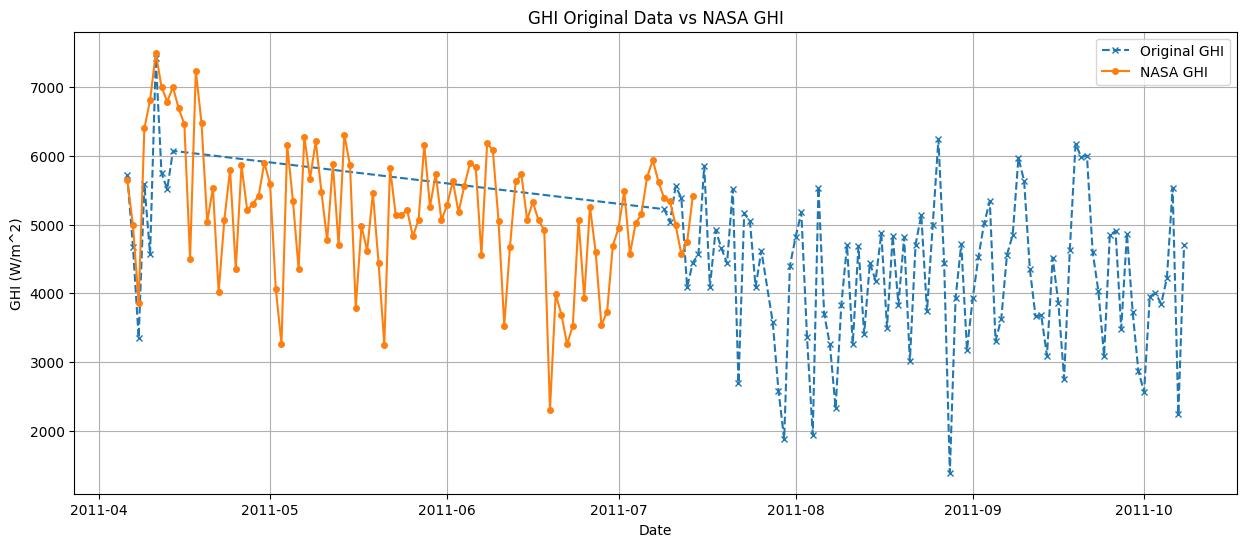

In [113]:
# plot the first 100 points of the predictions and the nasa data
plt.figure(figsize=(15, 6))
plt.plot(kampala.index[:100],kampala['ghi'][:100], label='Original GHI', marker='x', linestyle='--', markersize=4)
plt.plot(kampala_nasa.index[:100],kampala_nasa['ghi_nasa'][:100], label='NASA GHI', marker='o', linestyle='-', markersize=4)
plt.title('GHI Original Data vs NASA GHI')
plt.xlabel('Date')
plt.ylabel('GHI (W/m^2)')
plt.legend()
plt.grid()
plt.show()

## CAMSRAD Pull

In [51]:
#@title Cams Fetch
def fetch_cams_data(locations_dict, email, time_step='1d', identifier='cams_radiation', estimator='cams'):
    """
    Fetch CAMS radiation data for multiple locations using pvlib.

    Args:
        locations_dict (dict): Dictionary with location details from extract_location_metadata.
        email (str): Email address required for CAMS service.
        time_step (str): Time step for CAMS data (e.g., '1h', '1d'). Defaults to '1d'.
        identifier (str): CAMS service identifier (e.g., 'cams_radiation').
        estimator (str): Name to assign to the 'estimator' column.

    Returns:
        pd.DataFrame: DataFrame containing formatted CAMS data for all locations.
                      Returns an empty DataFrame if fetching fails for all locations.
    """
    all_data = []
    ghi_cols = ['ghi_extra', 'ghi_clear', 'bhi_clear', 'dhi_clear', 'dni_clear', 'ghi', 'bhi', 'dhi', 'dni']

    for location_name, details in locations_dict.items():
        print(f"Fetching CAMS data for: {location_name} ({details['Start Time']} to {details['End Time']})")
        try:
            start_dt = pd.to_datetime(details['Start Time'])
            end_dt = pd.to_datetime(details['End Time'])

            data, metadata = pvlib.iotools.get_cams(
                latitude=details['Latitude'],
                longitude=details['Longitude'],
                start=start_dt,
                end=end_dt,
                email=email,
                time_step=time_step,
                identifier=identifier,
                timeout=180
            )
            # convert from W/m^2 to Wh/m^2
            for col in ghi_cols:
                data[col] = data[col] * 24

            df_loc = data.copy()

            df_loc['location'] = location_name
            df_loc['estimator'] = estimator

            df_loc.index.name = 'datetime'

            all_data.append(df_loc)

        except Timeout:
             print(f"Timeout error fetching CAMS data for {location_name}")
        except requests.exceptions.RequestException as e: # pvlib uses requests internally
             print(f"Network error fetching CAMS data for {location_name}: {e}")
        except ImportError:
            raise ImportError("pvlib library is required for CAMS fetching. Please install it.")
        except Exception as e:
            print(f"Failed to fetch or process CAMS data for {location_name}: {e}") # Print the error


    if not all_data:
        print("No CAMS data successfully fetched.")
        return pd.DataFrame()

    final_df = pd.concat(all_data)
    return final_df

cams_email = 'mukiibirogerz@gmail.com'
kampala_cams = fetch_cams_data(kampala_dict, email=cams_email)
tororo_cams = fetch_cams_data(tororo_dict, email=cams_email)

Fetching CAMS data for: kampala (2011-04-06 to 2023-01-22)
Fetching CAMS data for: tororo (2011-03-08 to 2017-11-22)


In [138]:
# Process cams data
def process_cams_data(df):
	"""
	Process CAMS data to rename columns and convert units.

	Args:
			df (pd.DataFrame): DataFrame containing CAMS data.

	Returns:
			pd.DataFrame: Processed DataFrame with renamed columns and converted units.
	"""
	df = df.copy()
	df = df.rename(columns={
			'ghi_extra': 'ghi_extra_cams',
			'ghi_clear': 'ghi_clear_cams',
			'bhi_clear': 'bhi_clear_cams',
			'dhi_clear': 'dhi_clear_cams',
			'dni_clear': 'dni_clear_cams',
			'ghi': 'ghi_cams',
			'bhi': 'bhi_cams',
			'dhi': 'dhi_cams',
			'dni': 'dni_cams'
	})

	# list of columns to convert from Wh/m^2 to kWh/m^2
	irradiance_cols = [
		'ghi_extra_cams', 'ghi_clear_cams', 'bhi_clear_cams', 'dhi_clear_cams',
		'dni_clear_cams', 'ghi_cams', 'bhi_cams', 'dhi_cams', 'dni_cams'
	]
 
	# convert all irradiance from Wh/m^2 to kWh/m^2
	for col in irradiance_cols:
		if col in df.columns:
			df[col] = df[col] / 1000
		else:
			print(f"Warning: {col} not found in DataFrame columns.")
	# compute kt_cams from ghi_cams and ghi_clear_cams
	df['kt_cams'] = df['ghi_cams'] / df['ghi_clear_cams']
	
 
 
	return df

In [139]:
kampala_cams_new = process_cams_data(kampala_cams)
tororo_cams_new = process_cams_data(tororo_cams)

In [140]:
#@title Merge data
def merge_dataframes(df1, df2, loc_dict):
	"""
	Merge two DataFrames on the 'datetime' index and 'location' column.

	Args:
			df1 (pd.DataFrame): First DataFrame to merge.
			df2 (pd.DataFrame): Second DataFrame to merge.

	Returns:
			pd.DataFrame: Merged DataFrame with data from both input DataFrames.
	"""
	merged_df = pd.merge(df1, df2, on=['datetime', 'location'], how='outer')
 
	# sort the index
	merged_df.sort_index(inplace=True)
 
	# add latitude and longitude from meta data
	for location in loc_dict.keys():
		lat = loc_dict[location]['Latitude']
		lon = loc_dict[location]['Longitude']
		merged_df.loc[merged_df['location'] == location, 'latitude'] = lat
		merged_df.loc[merged_df['location'] == location, 'longitude'] = lon
		if 'latitude' not in merged_df.columns:
			print(f"Warning: latitude column not found in DataFrame.")
		if 'longitude' not in merged_df.columns:
			print(f"Warning: longitude column not found in DataFrame.")
  
	# add dayoftheyear column, and month column
	merged_df['day_of_year'] = merged_df.index.dayofyear
	merged_df['Month'] = merged_df.index.month

	# compute altitude using pvlib
	merged_df = get_altitude_pvib(merged_df)
 
 	# compute sin and cos of the day of the year
	merged_df['dayofyear_sin'] = merged_df['day_of_year'].apply(lambda x: math.sin(2 * math.pi * x / 365))
	merged_df['dayofyear_cos'] = merged_df['day_of_year'].apply(lambda x: math.cos(2 * math.pi * x / 365))
	return merged_df

In [141]:
kampala_merged = merge_dataframes(kampala_nasa, kampala_cams_new, kampala_dict)
tororo_merged = merge_dataframes(tororo_nasa, tororo_cams_new, tororo_dict)

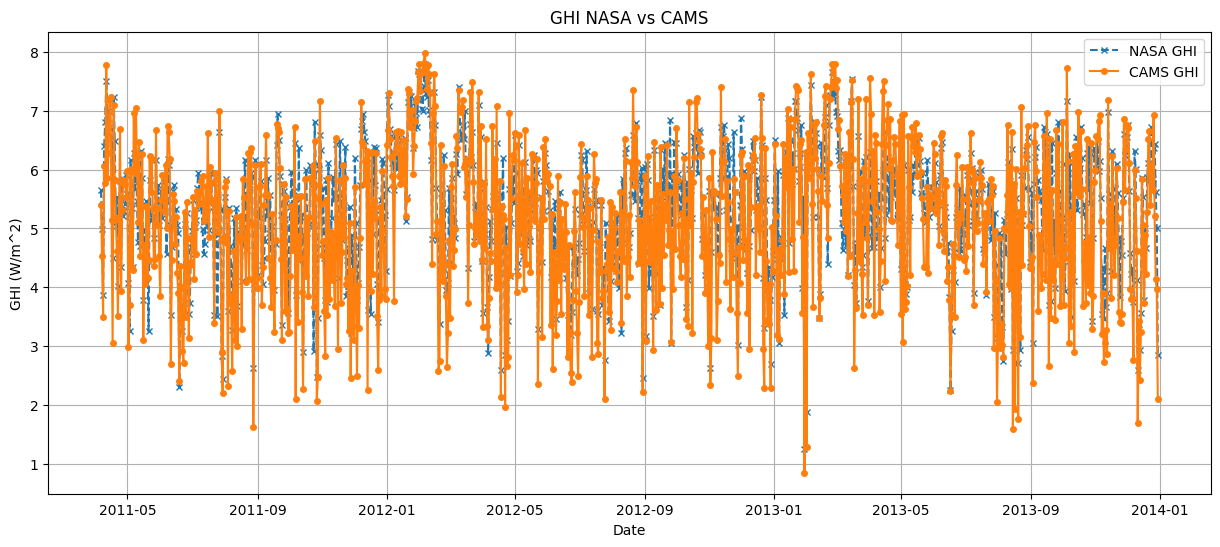

In [142]:
# plot the first 100 points of the ghi_nasa and ghi_cams
plt.figure(figsize=(15, 6))
plt.plot(kampala_merged.index[:1000],kampala_merged['ghi_nasa'][:1000], label='NASA GHI', marker='x', linestyle='--', markersize=4)
plt.plot(kampala_merged.index[:1000],kampala_merged['ghi_cams'][:1000], label='CAMS GHI', marker='o', linestyle='-', markersize=4)
plt.title('GHI NASA vs CAMS')
plt.xlabel('Date')
plt.ylabel('GHI (W/m^2)')
plt.legend()
plt.grid()
plt.show()

In [116]:
kampala_merged

,location,estimator_x,ghi_nasa,bhi_nasa,dni_nasa,clear_ghi_nasa,T2M,RH2M,PS,WS2M,...,Reliability,estimator_y,kt_cams,latitude,longitude,day_of_year,Month,altitude,dayofyear_sin,dayofyear_cos
datetime,,,,,,,,,,,,,,,,,,,,,
2011-04-06,kampala,nasa_power,5650.0,2800.0,2730.0,8750.0,23.25,77.20,88.35,1.03,...,0.9844,cams,0.712567,0.333542,32.56863,96,4,1202.0,0.996659,-0.081676
2011-04-07,kampala,nasa_power,4990.0,3120.0,1640.0,8690.0,22.72,77.90,88.32,1.17,...,0.9840,cams,0.602078,0.333542,32.56863,97,4,1202.0,0.995105,-0.098820
2011-04-08,kampala,nasa_power,3860.0,2450.0,1250.0,8690.0,22.02,83.28,88.48,1.45,...,0.9847,cams,0.473487,0.333542,32.56863,98,4,1202.0,0.993257,-0.115935
2011-04-09,kampala,nasa_power,6400.0,2360.0,4750.0,8820.0,22.90,76.79,88.57,1.09,...,0.9795,cams,0.788010,0.333542,32.56863,99,4,1202.0,0.991114,-0.133015
2011-04-10,kampala,nasa_power,6810.0,2190.0,5770.0,8830.0,22.88,77.99,88.51,1.88,...,0.9847,cams,0.735575,0.333542,32.56863,100,4,1202.0,0.988678,-0.150055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-01-18,kampala,nasa_power,6130.0,2370.0,5090.0,8330.0,23.71,61.87,88.48,1.46,...,0.9840,cams,0.666123,0.333542,32.56863,18,1,1202.0,0.304921,0.952378
2023-01-19,kampala,nasa_power,6560.0,2490.0,5150.0,8360.0,24.24,62.78,88.45,1.54,...,0.9840,cams,0.928555,0.333542,32.56863,19,1,1202.0,0.321270,0.946988
2023-01-20,kampala,nasa_power,5200.0,2540.0,3180.0,8530.0,24.12,65.40,88.41,1.17,...,0.9837,cams,0.614081,0.333542,32.56863,20,1,1202.0,0.337523,0.941317


# Test Models

In [105]:
#@title imports

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.interpolate import interp1d
from scipy.stats import ks_2samp
from sklearn.svm import SVR
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import re


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import joblib
import os
import warnings

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.stats import ks_2samp

# Suppress specific warnings if needed (e.g., from plotting)
warnings.filterwarnings("ignore", category=UserWarning)

# ==============================================================================
# Helper Functions (Metrics, Plots, CPI)
# ==============================================================================

def calculate_metrics(y_true, y_pred, model_name="Model", verbose=True, latex=False):
    """
    Calculates standard regression metrics including the Kolmogorov-Smirnov statistic (KSI).

    Args:
        y_true (array-like): Ground truth values.
        y_pred (array-like): Predicted values.
        model_name (str): Name of the model for printing.
        verbose (bool): Whether to print the metrics.
        latex (bool): Whether to print the metrics in LaTeX table format.

    Returns:
        dict: Dictionary containing the calculated metrics: RMSE, MAE, R2, MBE, KSI.
    """
    if verbose or latex:
        print(f"--- {model_name} Performance ---")
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    valid_preds = np.isfinite(y_pred) & np.isfinite(y_true) # Check both true and pred
    if not np.all(valid_preds):
        num_invalid = np.sum(~valid_preds)
        print(f"Warning: Found {num_invalid} non-finite predictions or true values for {model_name}. Evaluating only on {len(y_true) - num_invalid} finite pairs.")
        y_true = y_true[valid_preds]
        y_pred = y_pred[valid_preds]
        if len(y_true) == 0:
            print(f"Error: No valid finite pairs left to evaluate for {model_name}.")
            return {"RMSE": np.nan, "MAE": np.nan, "R2": np.nan, "MBE": np.nan, "KSI": np.nan}

    if len(y_true) == 0: # Should be caught above, but double-check
         print(f"Error: Zero length arrays for evaluation for {model_name}.")
         return {"RMSE": np.nan, "MAE": np.nan, "R2": np.nan, "MBE": np.nan, "KSI": np.nan}


    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    if np.var(y_true) > 1e-9:
        r2 = r2_score(y_true, y_pred)
    else:
        print(f"Warning: Ground truth for {model_name} has near-zero variance. R² is NaN.")
        r2 = np.nan
    mbe = np.mean(y_pred - y_true)
    if len(y_true) > 1 and len(y_pred) > 1:
         ks_stat, _ = ks_2samp(y_true, y_pred)
    else:
        ks_stat = np.nan

    if verbose:
        print(f"RMSE: {rmse:.4f}")
        print(f"MAE:  {mae:.4f}")
        print(f"R²:   {r2:.4f}")
        print(f"MBE:  {mbe:.4f}")
        print(f"KSI:  {ks_stat:.4f}")
        if verbose or latex:
             print("-" * (len(model_name) + 20))
    if latex:
        print('Latex version')
        print(f"{model_name} & {rmse:.4f} & {mae:.4f} & {r2:.4f} & {mbe:.4f} & {ks_stat:.4f} \\\\")

    return {"RMSE": rmse, "MAE": mae, "R2": r2, "MBE": mbe, "KSI": ks_stat}

def plot_ghi_comparison(index, y_true, y_corrected, y_est, num_points=100, title="GHI Comparison"):
    """Plots the comparison of different GHI estimates (Time Series Plot)."""
    plt.figure(figsize=(15, 6))
    num_points = min(num_points, len(index))
    plt.plot(index[:num_points], y_corrected[:num_points], label='Corrected GHI (Model Output)', marker='.', linestyle='-', markersize=4, color='orange')
    plt.plot(index[:num_points], y_true[:num_points], label='Ground Truth GHI', marker='x', linestyle='--', markersize=4, color='black')
    plt.plot(index[:num_points], y_est[:num_points], label='Original Satellite GHI', marker='o', linestyle=':', markersize=4, color='blue', alpha=0.7)
    plt.xlabel("Time")
    plt.ylabel("Daily GHI (W/m² or Wh/m²/day)") # Adjust unit based on data
    plt.title(title)
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_scatter_comparison(y_true, y_pred_model, y_pred_baseline, model_name, baseline_name, title="Scatter Plot Comparison"):
    """Plots scatter plots comparing model and baseline predictions to ground truth."""
    plt.figure(figsize=(12, 5))
    max_val = max(y_true.max(), y_pred_model.max(), y_pred_baseline.max()) * 1.05
    min_val = min(y_true.min(), y_pred_model.min(), y_pred_baseline.min()) * 0.95
    if min_val > 0: min_val = 0 # Ensure axes start near 0 if all values are positive

    # Plot Model vs True
    plt.subplot(1, 2, 1)
    plt.scatter(y_true, y_pred_model, alpha=0.5, label=f'{model_name} Preds', s=10)

    # find line of best fit
    z = np.polyfit(y_true, y_pred_model, 1)
    p = np.poly1d(z)
    plt.plot(y_true, p(y_true), "r--", label='line of Best fit')
    # equation of estimate
    equation = f"y = {z[0]:.2f}x + {z[1]:.2f}"
    plt.text(0.05, 0.95, equation, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')

    plt.xlabel("Ground Truth GHI")
    plt.ylabel("Predicted GHI")
    plt.title(f"{model_name} vs Ground Truth")
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.grid(True, linestyle='--', linewidth=0.5)
    plt.legend()
    plt.gca().set_aspect('equal', adjustable='box')

    # Plot Baseline vs True
    plt.subplot(1, 2, 2)
    plt.scatter(y_true, y_pred_baseline, alpha=0.5, label=f'{baseline_name} Preds', s=10, color='blue')

    # find line of best fit
    z = np.polyfit(y_true, y_pred_baseline, 1)
    p = np.poly1d(z)
    plt.plot(y_true, p(y_true), "r--", label='line of Best fit')
    equation = f"y = {z[0]:.2f}x + {z[1]:.2f}"
    plt.text(0.05, 0.95, equation, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')

    plt.xlabel("Ground Truth GHI")
    plt.ylabel("Predicted GHI")
    plt.title(f"{baseline_name} vs Ground Truth")
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.grid(True, linestyle='--', linewidth=0.5)
    plt.legend()
    plt.gca().set_aspect('equal', adjustable='box')

    plt.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

def plot_cdf_comparison(y_true, y_pred_model, y_pred_baseline, model_name, baseline_name, title="CDF Comparison"):
    """Plots empirical CDFs of ground truth, model predictions, and baseline predictions."""
    plt.figure(figsize=(10, 6))

    ecdf_true = ECDF(y_true)
    ecdf_model = ECDF(y_pred_model)
    ecdf_baseline = ECDF(y_pred_baseline)

    x_vals = np.linspace(min(y_true.min(), y_pred_model.min(), y_pred_baseline.min()),
                         max(y_true.max(), y_pred_model.max(), y_pred_baseline.max()),
                         500)

    plt.plot(x_vals, ecdf_true(x_vals), label='Ground Truth GHI', color='black', linestyle='--')
    plt.plot(x_vals, ecdf_model(x_vals), label=f'{model_name} Corrected GHI', color='orange', linestyle='-')
    plt.plot(x_vals, ecdf_baseline(x_vals), label=f'{baseline_name} GHI', color='blue', linestyle=':')

    plt.xlabel("Daily GHI (W/m² or Wh/m²/day)") # Adjust unit
    plt.ylabel("Cumulative Probability (CDF)")
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

def calculate_cpi(model_metrics, baseline_metrics, weights={'RMSE': 0.4, 'MAE': 0.3, 'R2': 0.3}):
    """
    Calculates a Combined Performance Index (CPI) based on relative metric improvement.
    Higher CPI indicates better overall performance relative to the baseline.

    Args:
        model_metrics (dict): Metrics dictionary for the ML model.
        baseline_metrics (dict): Metrics dictionary for the baseline (e.g., raw satellite).
        weights (dict): Weights for combining normalized metrics (must sum to 1).

    Returns:
        float: The Combined Performance Index (CPI), or NaN if calculation fails.
    """
    cpi = 0.0
    total_weight = sum(weights.values())
    if not np.isclose(total_weight, 1.0):
        print("Warning: CPI weights do not sum to 1. Normalizing weights.")
        weights = {k: v / total_weight for k, v in weights.items()}

    # --- RMSE Relative Improvement ---
    rmse_model = model_metrics.get('RMSE')
    rmse_baseline = baseline_metrics.get('RMSE')
    if rmse_model is not None and rmse_baseline is not None and not np.isnan(rmse_model) and not np.isnan(rmse_baseline) and rmse_baseline > 1e-9:
        # Improvement: Higher is better. Max(0, ...) ensures no negative contribution if model is worse.
        rrmse_imp = max(0, (rmse_baseline - rmse_model) / rmse_baseline)
        cpi += weights.get('RMSE', 0) * rrmse_imp
        print(f"CPI: Relative RMSE Improvement = {rrmse_imp:.4f} (Weight: {weights.get('RMSE', 0)})")
    else:
        print("CPI: Cannot calculate relative RMSE improvement (NaN or zero baseline).")
        return np.nan # Cannot calculate CPI if essential component is missing

    # --- MAE Relative Improvement ---
    mae_model = model_metrics.get('MAE')
    mae_baseline = baseline_metrics.get('MAE')
    if mae_model is not None and mae_baseline is not None and not np.isnan(mae_model) and not np.isnan(mae_baseline) and mae_baseline > 1e-9:
        # Improvement: Higher is better.
        rmae_imp = max(0, (mae_baseline - mae_model) / mae_baseline)
        cpi += weights.get('MAE', 0) * rmae_imp
        print(f"CPI: Relative MAE Improvement = {rmae_imp:.4f} (Weight: {weights.get('MAE', 0)})")
    else:
        print("CPI: Cannot calculate relative MAE improvement (NaN or zero baseline).")
        return np.nan

    # --- R2 Score (Use directly, ensuring it's non-negative) ---
    r2_model = model_metrics.get('R2')
    if r2_model is not None and not np.isnan(r2_model):
        # Clamp R2 >= 0 for CPI calculation, as negative R2 indicates very poor fit.
        r2_term = max(0, r2_model)
        cpi += weights.get('R2', 0) * r2_term
        print(f"CPI: R2 Score contribution = {r2_term:.4f} (Weight: {weights.get('R2', 0)})")
    else:
        print("CPI: Cannot include R2 score (NaN).")
        return np.nan

    print(f"--- Final CPI = {cpi:.4f} ---")
    return cpi

# ==============================================================================
# Main Correction Class (Modified for Grid Search)
# ==============================================================================

class SolarGHIErrorCorrection:
    """
    (Docstring remains largely the same, handles training, evaluation, prediction)
    """
    def __init__(self, model_type='random_forest', model_params=None, save_path=None):
        # (Initialization remains the same)
        self.model_type = model_type
        self.model_params = model_params or {}
        self.save_path = save_path
        self.model = None
        self.scaler = None
        self.feature_cols = None
        self.ground_truth_col = None
        self.est_ghi_col = None
        self.is_trained = False
        self.best_params_ = None # Store best params found by GridSearch

        if save_path and not os.path.exists(save_path):
            os.makedirs(save_path)

    def _create_model(self, use_best_params=False):
        """Create the model, optionally using best_params_ found by GridSearch."""
        # Use stored best parameters if requested and available
        params_to_use = self.best_params_ if use_best_params and self.best_params_ else self.model_params

        # --- Model creation logic remains the same, but uses params_to_use ---
        if self.model_type == 'random_forest':
            n_estimators = params_to_use.get('n_estimators', 200)
            max_depth = params_to_use.get('max_depth', None)
            min_samples_leaf = params_to_use.get('min_samples_leaf', 5)
            random_state = params_to_use.get('random_state', 42)
            model_params_copy = params_to_use.copy()
            for key in ['n_estimators', 'max_depth', 'min_samples_leaf', 'random_state']:
                 model_params_copy.pop(key, None)
            return RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, min_samples_leaf=min_samples_leaf,
                                        random_state=random_state, n_jobs=-1, **model_params_copy)
        elif self.model_type == 'linear':
            return LinearRegression(**params_to_use)
        elif self.model_type == 'ridge':
            if 'alpha' not in params_to_use: params_to_use['alpha'] = 1.0
            return Ridge(**params_to_use)
        elif self.model_type == 'svr':
             if 'kernel' not in params_to_use: params_to_use['kernel'] = 'rbf'
             if 'C' not in params_to_use: params_to_use['C'] = 1.0
             if 'epsilon' not in params_to_use: params_to_use['epsilon'] = 0.1
             return SVR(**params_to_use)
        elif self.model_type == 'xgboost':
             if 'n_estimators' not in params_to_use: params_to_use['n_estimators'] = 100
             if 'learning_rate' not in params_to_use: params_to_use['learning_rate'] = 0.1
             if 'max_depth' not in params_to_use: params_to_use['max_depth'] = 5
             if 'random_state' not in params_to_use: params_to_use['random_state'] = 42
             return xgb.XGBRegressor(objective='reg:squarederror', **params_to_use)
        else:
            raise ValueError(f"Unsupported model type: {self.model_type}")

    def train(self, df, feature_cols, ground_truth_col='ghi', est_ghi_col='ALLSKY_SFC_SW_DWN',
              test_size=0.2, scale_features=False,
              use_grid_search=False, param_grid=None, cv_splits=3, cv_scoring='neg_root_mean_squared_error', # GridSearch args
              plot_comparison=True, num_plot_points=100, verbose=True, latex=False):
        """
        Train the model, optionally using GridSearchCV for hyperparameter tuning.

        Args:
            df (pd.DataFrame): DataFrame containing all necessary columns, MUST be sorted by time index.
            feature_cols (list): List of column names to use as features.
            ground_truth_col (str): Name of the ground truth GHI column.
            est_ghi_col (str): Name of the original satellite GHI column.
            test_size (float): Proportion of the data to use for the test set (taken from the end).
            scale_features (bool): Whether to apply StandardScaler to features.
            use_grid_search (bool): Whether to perform GridSearchCV.
            param_grid (dict): Parameter grid for GridSearchCV. Required if use_grid_search is True.
            cv_splits (int): Number of splits for TimeSeriesSplit cross-validation.
            cv_scoring (str): Scoring metric for GridSearchCV (e.g., 'neg_root_mean_squared_error', 'r2').
            plot_comparison (bool): Whether to plot the test set results.
            num_plot_points (int): Number of points to show in the plot.
            verbose (bool): Print progress and metrics.
            latex (bool): Print metrics in LaTeX format.

        Returns:
            dict: A dictionary containing performance metrics and test set predictions, or None if error.
        """
        # --- Initial processing and split (same as before) ---
        self.feature_cols = feature_cols
        self.ground_truth_col = ground_truth_col
        self.est_ghi_col = est_ghi_col

        required_cols = [ground_truth_col, est_ghi_col] + feature_cols
        df_processed = df.dropna(subset=required_cols).copy()
        if df_processed.empty:
            print("Error: DataFrame is empty after dropping NaNs. Check input data and feature list.")
            return None

        target_col = 'bias'
        df_processed[target_col] = df_processed[self.ground_truth_col] - df_processed[self.est_ghi_col]
        X = df_processed[feature_cols]
        y = df_processed[target_col]
        original_est_ghi = df_processed[est_ghi_col]
        original_ground_truth = df_processed[ground_truth_col]

        n_samples = len(X)
        n_test = int(n_samples * test_size)
        n_train = n_samples - n_test
        if n_train <= 0 or n_test <= 0:
             print(f"Error: Not enough data for train/test split (Train: {n_train}, Test: {n_test}). Need more data or smaller test_size.")
             return None

        X_train, X_test = X.iloc[:n_train], X.iloc[n_train:]
        y_train, y_test = y.iloc[:n_train], y.iloc[n_train:]
        est_ghi_test = original_est_ghi.iloc[n_train:]
        ground_truth_test = original_ground_truth.iloc[n_train:]
        test_index = ground_truth_test.index

        # --- Feature Scaling (Applied before GridSearch/Training) ---
        if scale_features:
            if verbose: print("Applying StandardScaler to features...")
            self.scaler = StandardScaler()
            X_train_scaled = self.scaler.fit_transform(X_train)
            X_test_scaled = self.scaler.transform(X_test)
        else:
            self.scaler = None
            X_train_scaled = X_train.values # Ensure numpy array for consistency
            X_test_scaled = X_test.values

        # --- Model Training ---
        if use_grid_search:
            if not param_grid:
                raise ValueError("param_grid must be provided if use_grid_search is True.")

            print(f"\nPerforming GridSearchCV for {self.model_type}...")
            print(f"Parameter Grid: {param_grid}")
            print(f"CV Splits (TimeSeriesSplit): {cv_splits}")
            print(f"Scoring Metric: {cv_scoring}")

            base_estimator = self._create_model() # Create a base instance
            # TimeSeriesSplit is crucial for cross-validating time series data correctly
            tscv = TimeSeriesSplit(n_splits=cv_splits)

            grid_search = GridSearchCV(
                estimator=base_estimator,
                param_grid=param_grid,
                scoring=cv_scoring,
                cv=tscv,
                n_jobs=-1, # Use all available CPU cores
                verbose=1   # Show progress
            )

            # Fit GridSearch ONLY on the training data
            grid_search.fit(X_train_scaled, y_train)

            print("\nGridSearchCV Complete.")
            print(f"Best Parameters Found: {grid_search.best_params_}")
            print(f"Best CV Score ({cv_scoring}): {grid_search.best_score_:.4f}")

            self.best_params_ = grid_search.best_params_ # Store the best params
            self.model = grid_search.best_estimator_ # Use the best model found
            # Note: GridSearchCV automatically refits the best estimator on the whole training set by default

        else:
            # Train directly using initial or specified parameters
            print(f"\nTraining {self.model_type} with pre-defined parameters...")
            self.model = self._create_model() # Create instance with self.model_params
            self.model.fit(X_train_scaled, y_train)
            self.best_params_ = self.model_params # Store the params used

        print("Model training complete.")
        self.is_trained = True

        # Save model and scaler if a path is provided (Now includes best_params in metadata)
        if self.save_path:
            self._save_model() # Updated save includes best_params_

        # --- Evaluate on the held-out Test Set ---
        print(f"\nEvaluating final model on {n_test} test samples...")
        error_pred_test = self.model.predict(X_test_scaled)
        ghi_corrected_test = est_ghi_test + error_pred_test

        # --- Calculate Metrics ---
        if verbose or latex: print("\n--- Evaluating Final Model vs Ground Truth (Test Set) ---")
        model_metrics = calculate_metrics(ground_truth_test, ghi_corrected_test, self.model.__class__.__name__, verbose=verbose, latex=latex)

        if verbose or latex: print(f"\n--- Evaluating Baseline ({self.est_ghi_col}) vs Ground Truth (Test Set) ---")
        baseline_metrics = calculate_metrics(ground_truth_test, est_ghi_test, f"Baseline ({self.est_ghi_col})", verbose=verbose, latex=latex)

        # --- Store results ---
        results_dict = {
            "model_performance": model_metrics,
            "baseline_performance": baseline_metrics,
            "test_predictions": pd.DataFrame({
                "ground_truth": ground_truth_test,
                "corrected_ghi": ghi_corrected_test,
                "satellite_ghi": est_ghi_test
            }, index=test_index),
            "best_params": self.best_params_ # Include best params in results
        }

        # --- Plotting (using test set data) ---
        if plot_comparison:
            # Time Series Plot
            plot_ghi_comparison(
                index=results_dict["test_predictions"].index,
                y_true=results_dict["test_predictions"]["ground_truth"],
                y_corrected=results_dict["test_predictions"]["corrected_ghi"],
                y_est=results_dict["test_predictions"]["satellite_ghi"],
                num_points=min(num_plot_points, n_test),
                title=f"{self.model.__class__.__name__} Daily GHI Correction (Test Set)"
            )
            # Scatter Plot
            plot_scatter_comparison(
                 y_true=results_dict["test_predictions"]["ground_truth"],
                 y_pred_model=results_dict["test_predictions"]["corrected_ghi"],
                 y_pred_baseline=results_dict["test_predictions"]["satellite_ghi"],
                 model_name=self.model.__class__.__name__,
                 baseline_name=f"Baseline ({self.est_ghi_col})",
                 title="Scatter Plot Comparison (Test Set)"
            )
            # CDF Plot
            plot_cdf_comparison(
                 y_true=results_dict["test_predictions"]["ground_truth"],
                 y_pred_model=results_dict["test_predictions"]["corrected_ghi"],
                 y_pred_baseline=results_dict["test_predictions"]["satellite_ghi"],
                 model_name=self.model.__class__.__name__,
                 baseline_name=f"Baseline ({self.est_ghi_col})",
                 title="CDF Comparison (Test Set)"
            )

        # --- Calculate CPI ---
        if model_metrics and baseline_metrics and not any(np.isnan(m) for m in model_metrics.values()) and not any(np.isnan(m) for m in baseline_metrics.values()):
             print("\n--- Combined Performance Index (CPI) Calculation ---")
             cpi = calculate_cpi(model_metrics, baseline_metrics)
             results_dict["cpi"] = cpi
        else:
             print("\nSkipping CPI calculation due to missing or NaN metrics.")
             results_dict["cpi"] = np.nan


        return results_dict

    # --- predict, evaluate, _save_model, load_model methods remain largely the same ---
    # Minor update to _save_model to include best_params_
    def _save_model(self):
        """Save the trained model, scaler, and metadata including best params."""
        if not self.is_trained: print("Warning: Untrained model"); return
        if not self.save_path: print("Warning: No save path"); return
        try:
            model_path = os.path.join(self.save_path, f"{self.model_type}_model.joblib")
            joblib.dump(self.model, model_path)
            if self.scaler is not None:
                scaler_path = os.path.join(self.save_path, f"{self.model_type}_scaler.joblib")
                joblib.dump(self.scaler, scaler_path)
            metadata = {
                'feature_cols': self.feature_cols, 'ground_truth_col': self.ground_truth_col,
                'est_ghi_col': self.est_ghi_col, 'model_type': self.model_type,
                'model_params': self.model_params, # Initial params
                'best_params_': self.best_params_, # Best params found (could be same as initial if no GS)
                'scaler_used': self.scaler is not None
            }
            metadata_path = os.path.join(self.save_path, f"{self.model_type}_metadata.joblib")
            joblib.dump(metadata, metadata_path)
            print(f"Model artifacts saved to {self.save_path}")
        except Exception as e: print(f"Error saving model: {e}")

    # Load model needs to potentially read best_params_ too
    def load_model(self, model_dir=None):
        """Loads model, scaler, and metadata including best params."""
        load_path = model_dir or self.save_path
        if not load_path or not os.path.isdir(load_path): raise FileNotFoundError(f"Load directory not found: {load_path}")
        try:
            metadata_path = os.path.join(load_path, f"{self.model_type}_metadata.joblib")
            if not os.path.exists(metadata_path): raise FileNotFoundError(f"Metadata file not found: {metadata_path}")
            metadata = joblib.load(metadata_path)

            self.feature_cols = metadata.get('feature_cols')
            self.ground_truth_col = metadata.get('ground_truth_col')
            self.est_ghi_col = metadata.get('est_ghi_col')
            self.model_params = metadata.get('model_params', {})
            self.best_params_ = metadata.get('best_params_', None) # Load best params
            scaler_used = metadata.get('scaler_used', False)

            model_path = os.path.join(load_path, f"{self.model_type}_model.joblib")
            if not os.path.exists(model_path): raise FileNotFoundError(f"Model file not found: {model_path}")
            # Important: Recreate the model using the *best* parameters if they exist
            self.model = self._create_model(use_best_params=True)
            # Now load the state of the fitted model
            self.model = joblib.load(model_path)

            if scaler_used:
                scaler_path = os.path.join(load_path, f"{self.model_type}_scaler.joblib")
                if os.path.exists(scaler_path): self.scaler = joblib.load(scaler_path)
                else: print(f"Warning: Scaler file not found at {scaler_path}"); self.scaler = None
            else: self.scaler = None

            self.is_trained = True
            print(f"Model loaded from {load_path}. Best params: {self.best_params_}")
        except Exception as e: print(f"Error loading model: {e}"); self.is_trained = False

    # --- predict and evaluate methods remain the same ---
    def predict(self, df, return_error=False):
        """(No changes needed here)"""
        if not self.is_trained: raise RuntimeError("Model not trained.")
        required_cols = self.feature_cols + [self.est_ghi_col]
        if not all(col in df.columns for col in required_cols): raise ValueError(f"Missing columns: {set(required_cols) - set(df.columns)}")
        df_clean = df.dropna(subset=required_cols).copy()
        if df_clean.empty: return pd.Series(dtype=float)
        X = df_clean[self.feature_cols]
        X_scaled = self.scaler.transform(X) if self.scaler else X
        predicted_error = self.model.predict(X_scaled)
        if return_error: return pd.Series(predicted_error, index=df_clean.index, name='predicted_bias')
        else: return pd.Series(df_clean[self.est_ghi_col] + predicted_error, index=df_clean.index, name='corrected_ghi')

    def evaluate(self, df, plot_results=True, num_plot_points=200, verbose=True, latex=True):
        """(No changes needed here)"""
        if not self.is_trained: raise RuntimeError("Model not trained.")
        required_cols = self.feature_cols + [self.est_ghi_col, self.ground_truth_col]
        if not all(col in df.columns for col in required_cols): raise ValueError(f"Missing columns: {set(required_cols) - set(df.columns)}")
        df_clean = df.dropna(subset=required_cols).copy()
        if df_clean.empty: return {"model_performance": None, "baseline_performance": None}
        corrected_ghi = self.predict(df_clean)
        ground_truth = df_clean.loc[corrected_ghi.index, self.ground_truth_col]
        est_ghi = df_clean.loc[corrected_ghi.index, self.est_ghi_col]
        if verbose or latex: print("\n--- Evaluating Model Corrected GHI vs Ground Truth (Evaluation Data) ---")
        model_metrics = calculate_metrics(ground_truth, corrected_ghi, self.model.__class__.__name__, verbose=verbose, latex=latex)
        if verbose or latex: print(f"\n--- Evaluating Baseline ({self.est_ghi_col}) vs Ground Truth (Evaluation Data) ---")
        baseline_metrics = calculate_metrics(ground_truth, est_ghi, f"Baseline ({self.est_ghi_col})", verbose=verbose, latex=latex)
        if plot_results:
            plot_ghi_comparison(ground_truth.index, ground_truth, corrected_ghi, est_ghi, num_points=min(num_plot_points, len(ground_truth.index)), title=f"{self.model.__class__.__name__} GHI Correction (Evaluation Data)")
            plot_scatter_comparison(ground_truth, corrected_ghi, est_ghi, self.model.__class__.__name__, f"Baseline ({self.est_ghi_col})", "Scatter Plot Comparison (Evaluation Data)")
            plot_cdf_comparison(ground_truth, corrected_ghi, est_ghi, self.model.__class__.__name__, f"Baseline ({self.est_ghi_col})", "CDF Comparison (Evaluation Data)")
        return {"model_performance": model_metrics, "baseline_performance": baseline_metrics}


# ==============================================================================
# Factory Functions (Provided)
# ==============================================================================
def create_random_forest_model(save_path=None, **kwargs): return SolarGHIErrorCorrection(model_type='random_forest', model_params=kwargs, save_path=save_path)
def create_linear_regression_model(save_path=None, **kwargs): return SolarGHIErrorCorrection(model_type='linear', model_params=kwargs, save_path=save_path)
def create_ridge_regression_model(save_path=None, **kwargs): return SolarGHIErrorCorrection(model_type='ridge', model_params=kwargs, save_path=save_path)
def create_svr_model(save_path=None, **kwargs): return SolarGHIErrorCorrection(model_type='svr', model_params=kwargs, save_path=save_path)
def create_xgboost_model(save_path=None, **kwargs): return SolarGHIErrorCorrection(model_type='xgboost', model_params=kwargs, save_path=save_path)

In [143]:
# load random forest
rf_model = create_random_forest_model()
rf_model.load_model(model_dir='Data/irradiation_estimates/models')

Model loaded from Data/irradiation_estimates/models. Best params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 200}


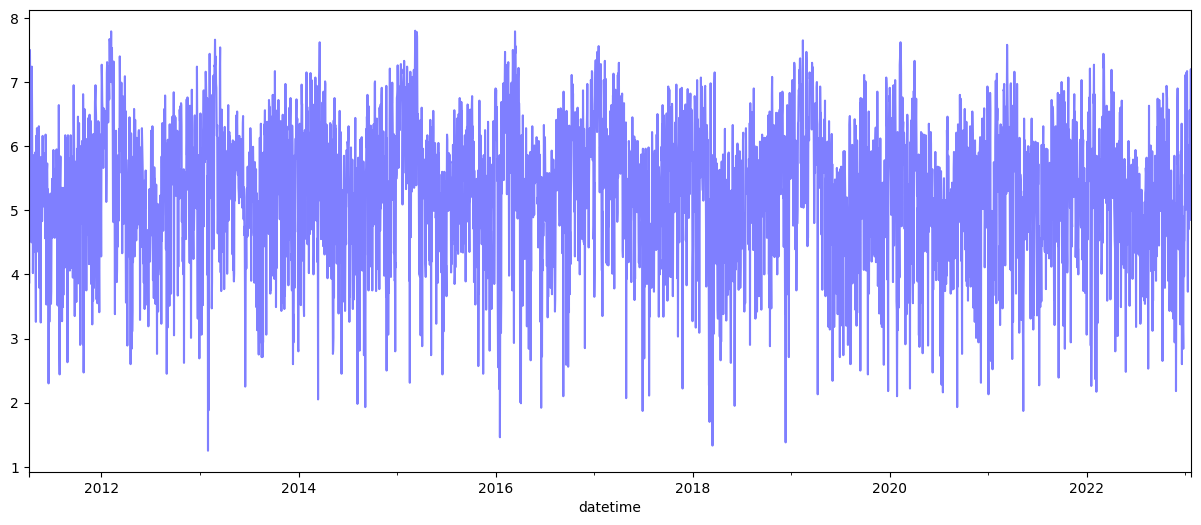

In [144]:
kampala_merged['ghi_nasa'].plot(label='GHI NASA', color='blue', alpha=0.5, figsize=(15, 6))
# kampala_merged['ghi_corrected'].plot(label='GHI Corrected', color='orange', alpha=0.5)
plt.show()

In [145]:
predictions = rf_model.predict(kampala_merged, return_error=False)

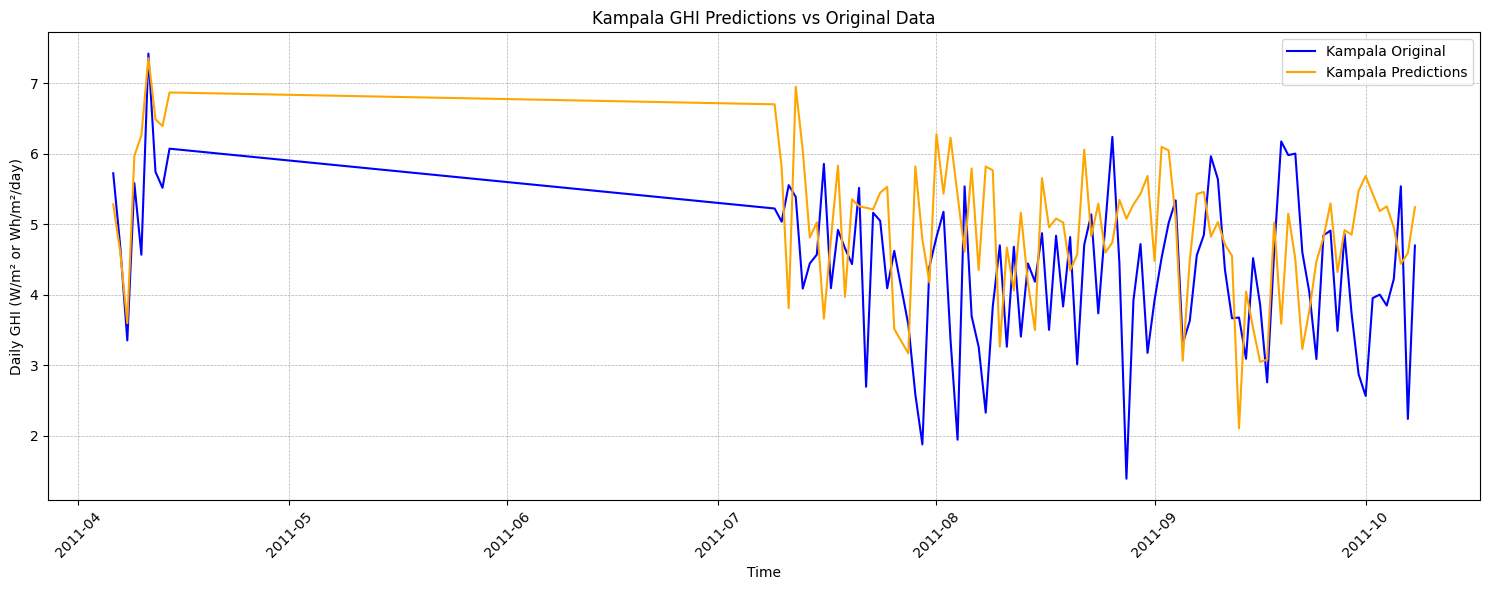

In [146]:
# plot the first 100 points of the predictions and the original data
plt.figure(figsize=(15, 6))
plt.plot(kampala.index[:100], kampala['ghi'][:100], label='Kampala Original', color='blue')
plt.plot(kampala.index[:100], predictions[:100], label='Kampala Predictions', color='orange')
plt.xlabel("Time")
plt.ylabel("Daily GHI (W/m² or Wh/m²/day)") # Adjust unit based on data
plt.title("Kampala GHI Predictions vs Original Data")
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

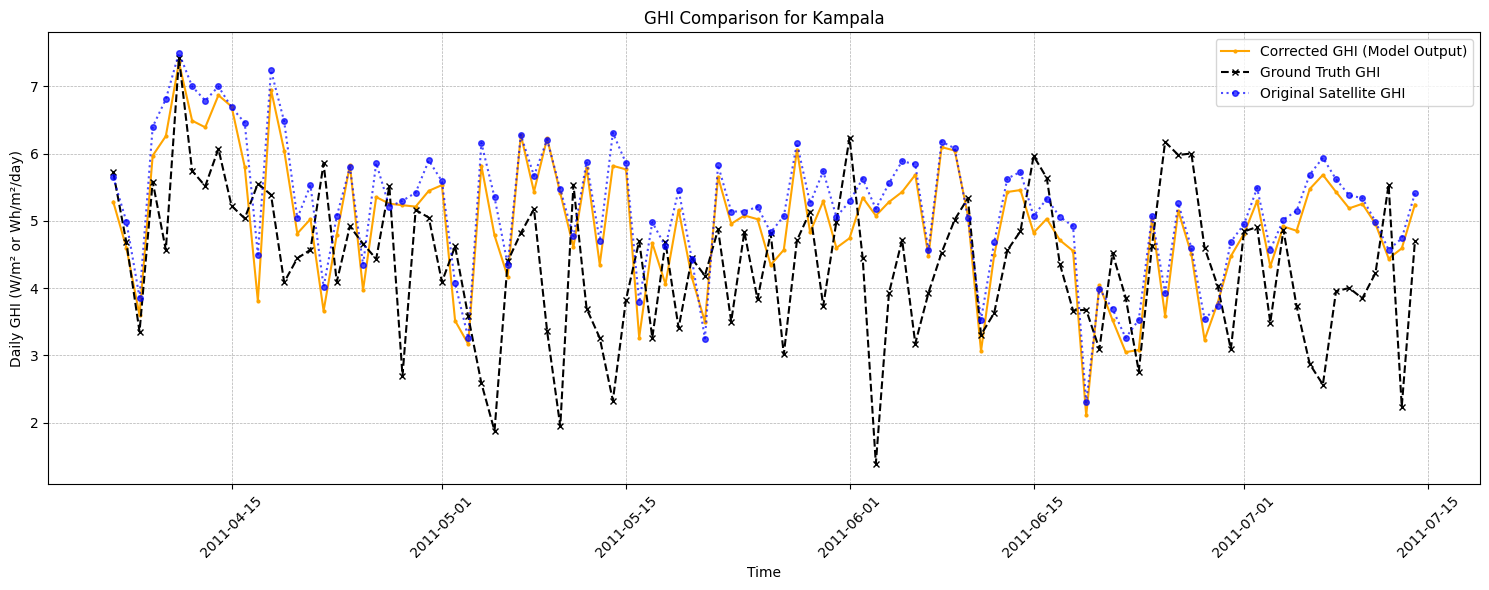

In [147]:
plot_ghi_comparison(kampala_merged.index, kampala['ghi'],
                    predictions, kampala_merged['ghi_nasa'],
                    num_points=100, title="GHI Comparison for Kampala")

In [148]:
xgboost_model = create_xgboost_model()
xgboost_model.load_model(model_dir='Data/irradiation_estimates/models')
predictions_xgboost = xgboost_model.predict(kampala_merged, return_error=False)

Model loaded from Data/irradiation_estimates/models. Best params: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 150, 'subsample': 0.9, 'random_state': 42}


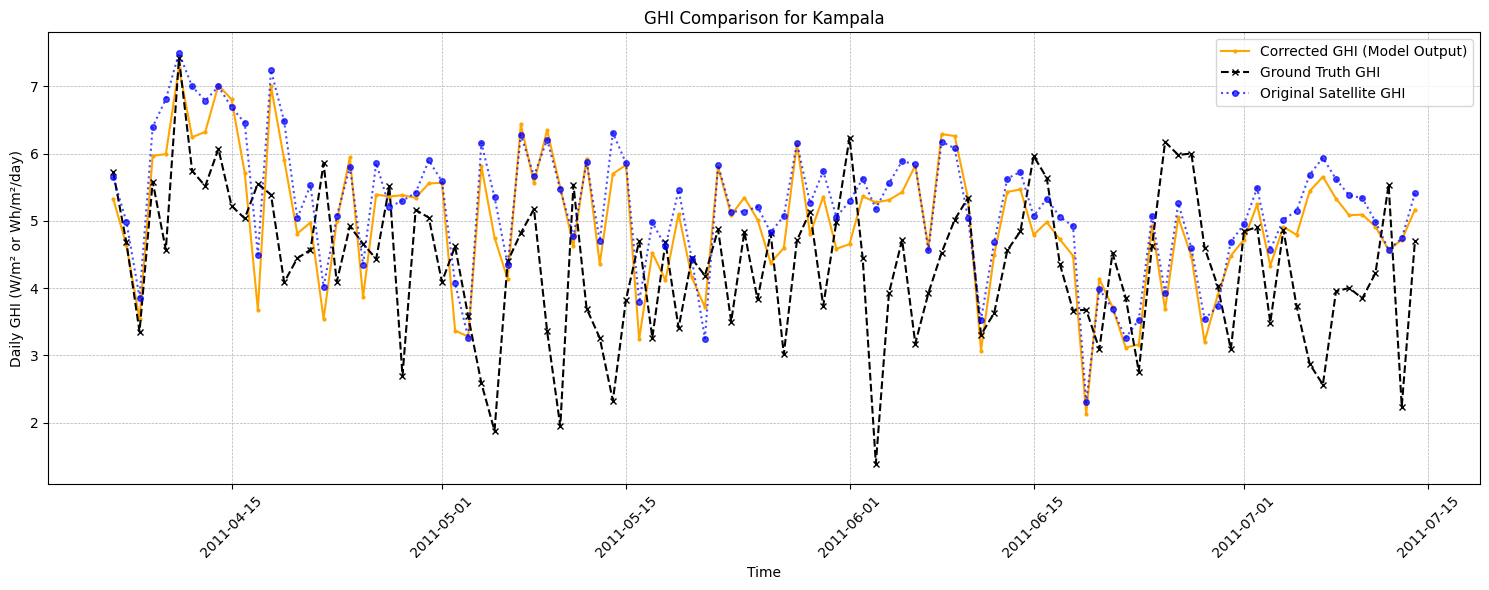

In [149]:
plot_ghi_comparison(kampala_merged.index, kampala['ghi'],
                    predictions_xgboost, kampala_merged['ghi_nasa'], num_points=100, title="GHI Comparison for Kampala")

In [150]:
kampala.shape

(1798, 5)

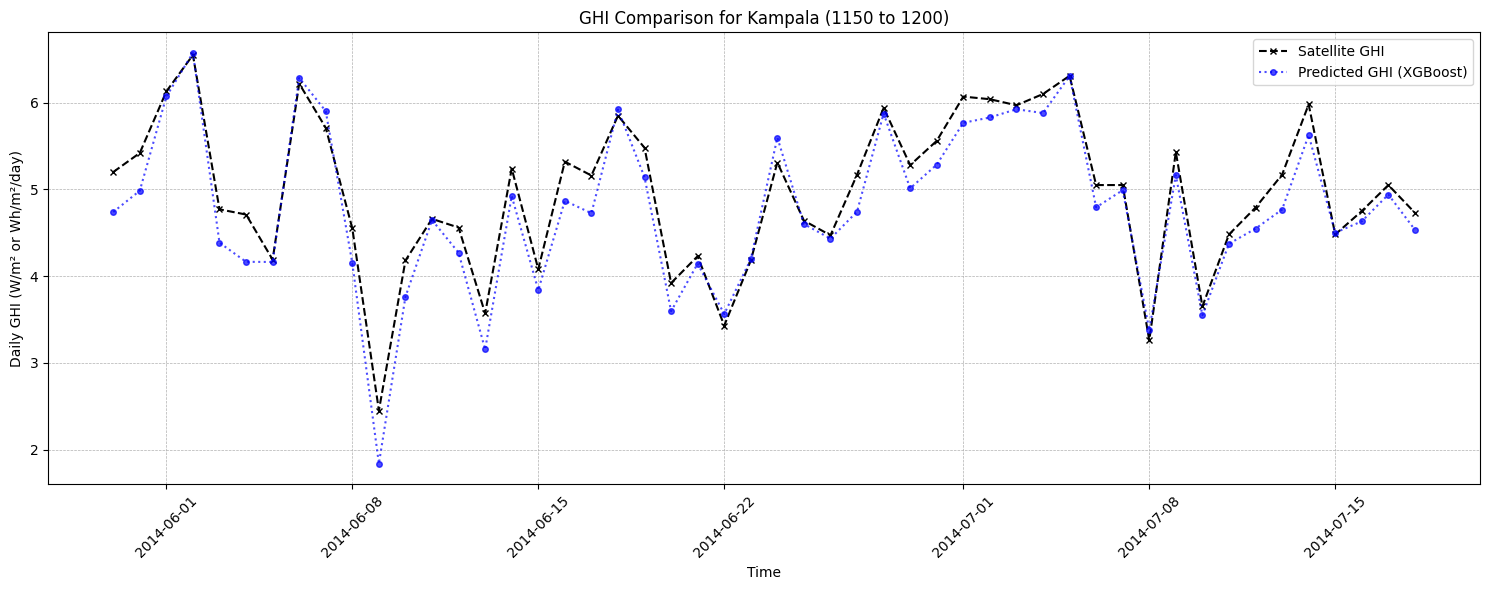

In [151]:
# plot the first 100 points of the predictions and the original data
lower_bound = 1150
upper_bound = 1200
plt.figure(figsize=(15, 6))
plt.plot(kampala_merged.index[lower_bound:upper_bound], kampala_merged['ghi_nasa'][lower_bound:upper_bound], label='Satellite GHI', marker='x', linestyle='--', markersize=4, color='black')
plt.plot(kampala_merged.index[lower_bound:upper_bound], predictions_xgboost[lower_bound:upper_bound], label='Predicted GHI (XGBoost)', marker='o', linestyle=':', markersize=4, color='blue', alpha=0.7)
plt.xlabel("Time")
plt.ylabel("Daily GHI (W/m² or Wh/m²/day)") # Adjust unit based on data
plt.title(f"GHI Comparison for Kampala ({lower_bound} to {upper_bound})")
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [152]:
error_pred_rf = rf_model.predict(kampala_merged, return_error=True)

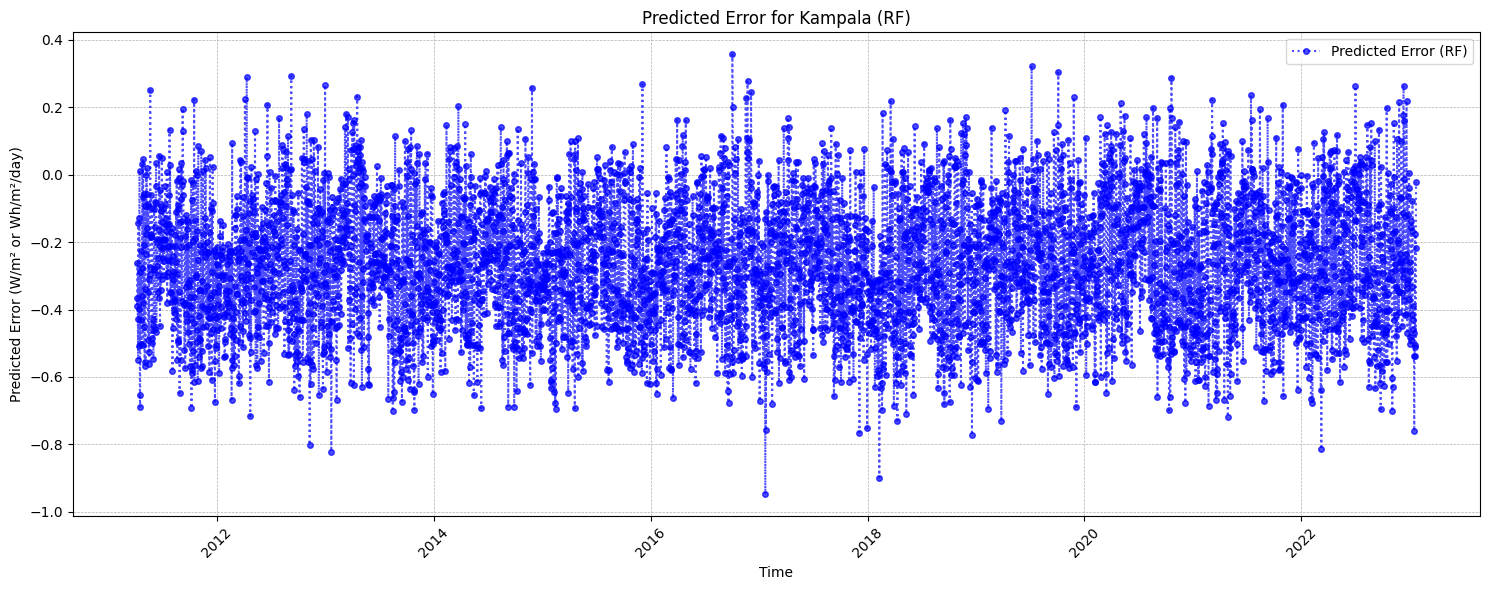

In [153]:
# plot error_pred_rf
plt.figure(figsize=(15, 6))
plt.plot(kampala_merged.index, error_pred_rf, label='Predicted Error (RF)', marker='o', linestyle=':', markersize=4, color='blue', alpha=0.7)
plt.xlabel("Time")
plt.ylabel("Predicted Error (W/m² or Wh/m²/day)") # Adjust unit based on data
plt.title("Predicted Error for Kampala (RF)")
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()